## Decision function, and logistic regression examples

In this example, we'll first take a look at the output of the decision function (scoring function) of a perceptron classifier, and then see a few examples of how we can use a logistic regression classifier.

We first read the usual Adult dataset.

In [1]:
import pandas as pd

train_data = pd.read_csv('adult_train.csv')

n_cols = len(train_data.columns)
Xtrain = train_data.iloc[:, :n_cols-1].to_dict('records')
Ytrain = train_data.iloc[:, n_cols-1]

test_data = pd.read_csv('adult_test.csv')
Xtest = test_data.iloc[:, :n_cols-1].to_dict('records')
Ytest = test_data.iloc[:, n_cols-1]

### Computing the prediction scores

We fit a perceptron classifier on the training set. (We use a `Pipeline` with a `StandardScaler` to make sure that the features have similar magnitudes.)

In [2]:
import numpy as np

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron

pipeline = make_pipeline(
    DictVectorizer(),
    StandardScaler(with_mean=False),
    Perceptron(max_iter=10)
)

pipeline.fit(Xtrain, Ytrain)

accuracy_score(Ytest, pipeline.predict(Xtest))

0.7909833548307843

We can compute the output scores by applying `decision_function` to the whole test set.

In [3]:
prediction_scores = pipeline.decision_function(Xtest)

To illustrate, here are the scores for the first 10 instances.

In [4]:
prediction_scores[:10]

array([-163.54286604,  -67.0962448 ,   14.86176883,  184.39518114,
       -282.73012294, -215.58067443, -194.05461982,   44.49920946,
       -131.98856037, -182.06385325])

In general, a large positive or negative score means that the classifier feels certain, while if the score is close to 0, the classifier is uncertain.

While the decision function scores give us some notion of the degree of "certainty", the scores don't mean anything on their own. It doesn't tell us anything that the score of the first instance happens to be -186, just that the classifier is more certain for this instance than e.g. for the second instance.

### Logistic regression

We'll investigate the logistic regression classifier, which can output probabilities in addition to the decision function.

We first fit a logistic regression classifier on the same training set.

In [5]:
from sklearn.linear_model import LogisticRegression

pipeline2 = make_pipeline(
    DictVectorizer(),
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=10000)
)

pipeline2.fit(Xtrain, Ytrain)

accuracy_score(Ytest, pipeline2.predict(Xtest))

0.8518518518518519

The function `predict_proba` computes probabilities for a set of instances. (In this case, all instances in the test set.)

In [6]:
probabilities = pipeline2.predict_proba(Xtest)

The probability output is a matrix with two columns (because there are two classes) and as many rows as there are instances.

In [7]:
probabilities.shape

(16281, 2)

In [8]:
probabilities

array([[0.99766891, 0.00233109],
       [0.87624464, 0.12375536],
       [0.63916544, 0.36083456],
       ...,
       [0.33353476, 0.66646524],
       [0.73704083, 0.26295917],
       [0.20598824, 0.79401176]])

Let's take a look at which output classes we're dealing with, just to understand the order in which they appear in the probability output. In this case, the low-earner class `<=50K` comes first, and then the high-earner class `>50K`.

In [9]:
pipeline2.classes_

array(['<=50K', '>50K'], dtype=object)

We take a look at the probabilities for the first instance. The probability for the first class (`<=50K`) is almost 1.

In [10]:
probabilities[0]

array([0.99766891, 0.00233109])

We will now consider the most confidently classified instances (for both classes) and the borderline cases.

We make a list consisting of, for each instance, (1) the probability of being a high earner, (2) the true output label, and (3) the features. We sort the list by the probabilities.

In [11]:
highearner_col = 1

prob_list = sorted( zip(probabilities[:,highearner_col], Ytest, Xtest), key=lambda r: r[0])

We print the first 5 in the sorted list. That is, the 5 instances where the classifier gives the lowest probability of being a high earner.

(This is just an exercise in using the predicted probabilities, but we can also use this as a way to explore the dataset and get an understanding the extreme cases.)

In [12]:
for prob, y, x in prob_list[:5]:
    print(prob, y, x)

1.7496652458915293e-09 <=50K {'age': 22, 'workclass': 'Private', 'education': 'Preschool', 'education-num': 1, 'marital-status': 'Never-married', 'occupation': 'Other-service', 'relationship': 'Own-child', 'race': 'Black', 'sex': 'Female', 'capital-gain': 594, 'capital-loss': 0, 'hours-per-week': 20, 'native-country': 'Jamaica'}
5.882939565708272e-09 <=50K {'age': 53, 'workclass': 'Private', 'education': 'Preschool', 'education-num': 1, 'marital-status': 'Never-married', 'occupation': 'Other-service', 'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Female', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 15, 'native-country': 'El-Salvador'}
7.800508220390651e-09 <=50K {'age': 21, 'workclass': 'Private', 'education': 'Preschool', 'education-num': 1, 'marital-status': 'Never-married', 'occupation': 'Farming-fishing', 'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 25, 'native-country': 'Mexico'}
9.

Conversely, we print the 5 last instances in the sorted list, corresponding to the 5 instances where the classifier is most certain that the person is a high earner.

In [13]:
for prob, y, x in prob_list[-5:]:
    print(prob, y, x)

0.9999999999999989 >50K {'age': 80, 'workclass': 'Self-emp-inc', 'education': 'Masters', 'education-num': 14, 'marital-status': 'Married-civ-spouse', 'occupation': 'Exec-managerial', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 99999, 'capital-loss': 0, 'hours-per-week': 54, 'native-country': 'United-States'}
0.9999999999999993 >50K {'age': 60, 'workclass': 'Federal-gov', 'education': 'Prof-school', 'education-num': 15, 'marital-status': 'Married-civ-spouse', 'occupation': 'Prof-specialty', 'relationship': 'Husband', 'race': 'Asian-Pac-Islander', 'sex': 'Male', 'capital-gain': 99999, 'capital-loss': 0, 'hours-per-week': 60, 'native-country': 'Philippines'}
0.9999999999999993 >50K {'age': 42, 'workclass': 'Self-emp-inc', 'education': 'Prof-school', 'education-num': 15, 'marital-status': 'Married-civ-spouse', 'occupation': 'Prof-specialty', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 99999, 'capital-loss': 0, 'hours-per-week': 

Finally, we print some of the borderline cases, where the classifier is uncertain about which class the person belongs to. We go through the list and print those instances where the probability is close to 0.5.

In [14]:
for prob, y, x in prob_list:
    if prob >= 0.4995 and prob < 0.5005:
        print(prob, y, x)

0.499559131168069 >50K {'age': 55, 'workclass': 'Private', 'education': 'Bachelors', 'education-num': 13, 'marital-status': 'Married-civ-spouse', 'occupation': 'Sales', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 20, 'native-country': 'United-States'}
0.4996064609882478 <=50K {'age': 61, 'workclass': 'Self-emp-not-inc', 'education': 'Prof-school', 'education-num': 15, 'marital-status': 'Divorced', 'occupation': 'Prof-specialty', 'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 50, 'native-country': 'United-States'}
0.49972273932591627 >50K {'age': 37, 'workclass': 'Private', 'education': 'Bachelors', 'education-num': 13, 'marital-status': 'Married-civ-spouse', 'occupation': 'Prof-specialty', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 40, 'native-country': '?'}
0.499722739325

### L1-regularized logistic regression

The following small example demonstrates the use of L1 regularization for logistic regression. This particular type of regularization does some feature selection, by setting the weights of these features to zero.

We make a pipeline that includes a L1-regularized logistic regression classifier. The hyperparameter `C` controls the strength of the regularizer: a low `C` penalizes the weights more aggressively.

In [15]:
pipeline3 = make_pipeline(
    DictVectorizer(),
    StandardScaler(with_mean=False),
    LogisticRegression(C=5e-3, penalty='l1', solver='liblinear')
)

pipeline3.fit(Xtrain, Ytrain);

We take out the last step of the pipeline, that is the actual classification object. The length of its weight vector is 107, meaning that we have 107 features in total.

In [16]:
clf = pipeline3.steps[2][1]
len(clf.coef_[0])

107

If we look at the weights, you can see that some of them are zero.

In [17]:
clf.coef_

array([[ 0.00000000e+00,  1.42799502e+00,  2.00618461e-01,
         0.00000000e+00, -1.13902202e-01, -1.26449330e-01,
        -1.87955530e-02, -2.70409405e-02, -5.71252659e-02,
        -1.39382169e-01, -9.24911546e-02,  0.00000000e+00,
         0.00000000e+00,  1.91975970e-01,  1.48490564e-01,
        -1.93155898e-01,  1.86846082e-01,  0.00000000e+00,
         1.53828399e-01, -2.51782837e-02,  6.70125213e-02,
        -2.79773200e-01,  0.00000000e+00,  0.00000000e+00,
        -5.77432747e-02, -7.39427902e-01, -1.29180595e-01,
        -6.10803061e-02, -5.96345979e-03,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

We count the number of non-zero weights. (In practice, we count the number of weights that are outside a tiny distance from zero.) As you can see, there are 62 non-zero weights, which means that several of the features have been disabled.

In [18]:
almost_zero = 1e-8

sum(np.abs(clf.coef_[0]) > almost_zero)

50

Even though we removed many features, we still have a good accuracy. However, if you try to decrease `C` even further, we will underfit and the accuracy will start to go down as we start to remove useful features.

In [19]:
accuracy_score(Ytest, pipeline3.predict(Xtest))

0.8527731711811314

Here are also some plots that show how $C$ affects the number of features and the accuracy on the test set.

In [20]:
acc = []
n_feats = []

log_C_range = np.arange(-4, 0.25, 0.25)

for log_C in log_C_range:    
    pipeline4 = make_pipeline(
        DictVectorizer(),
        StandardScaler(with_mean=False),
        LogisticRegression(C=10**log_C, penalty='l1', solver='liblinear')
    )
    pipeline4.fit(Xtrain, Ytrain);
    
    n_feats.append(sum(np.abs(pipeline4.steps[2][1].coef_[0]) > almost_zero))
    acc.append(accuracy_score(Ytest, pipeline4.predict(Xtest)))
    

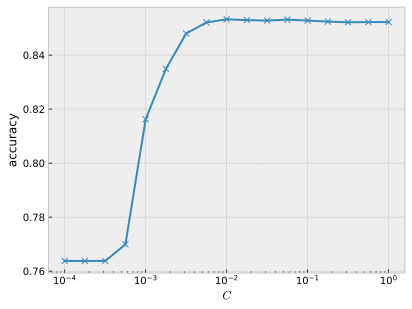

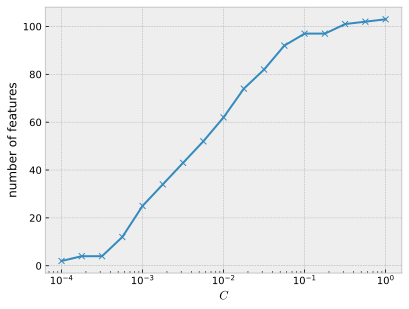

In [21]:
import matplotlib.pyplot as plt

# plot cosmetics
%config InlineBackend.figure_format = 'svg' 
plt.style.use('bmh')

plt.figure()
plt.semilogx(10**log_C_range, acc, 'x-')
plt.xlabel('$C$')
plt.ylabel('accuracy');
plt.figure()
plt.semilogx(10**log_C_range, n_feats, 'x-')
plt.xlabel('$C$')
plt.ylabel('number of features');

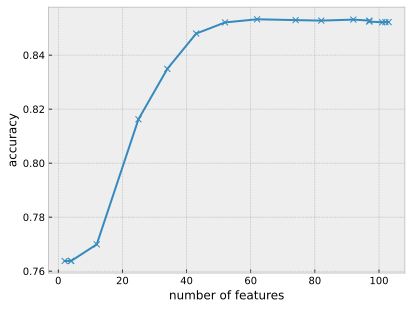

In [22]:
plt.plot(n_feats, acc, 'x-');
plt.xlabel('number of features');
plt.ylabel('accuracy');

# How well-calibrated are the probabilities?

We want to investigate how well the probabilities output by a logistic regression model correspond to "uncertainties" as we would understand them. For instance, if the model outputs a probability (of the positive class) of 0.6, we would like there to be around 60% chance of classifying this correctly as positive.

So we write a function that implements this idea. We first sort the instances by the predicted probability. The instances are then divided into "buckets", by default 100 instances in each bucket. For each bucket, we compute the average predicted probability, and the proportion of positive. We want the probability to be similar to this proportion.

We finally plot the probability against the proportions positive. For a well-calibrated probability model, this plot should be near the diagonal.

In [23]:
def check_probs(probs, Y, step=100):
    sorted_ixs = probs.argsort()
    probs = probs[sorted_ixs]
    Y = Y[sorted_ixs]
    
    p_means = []
    Y_means = []
    
    for start in range(0, len(Y), step):
        
        p_means.append( probs[start: start+step].mean() )
        Y_means.append( Y[start: start+step].mean() )
        
    plt.figure(figsize=(5,5))
    plt.plot(p_means, Y_means, '.', markersize=10.0)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1.0)
    plt.xlabel('Predicted probability')
    plt.ylabel('Proportion positive')
        

We carry out this kind of analysis for the logistic regression model trained on the Adult dataset.

It turns out that the probabilities of this model actually seem to be quite well calibrated.

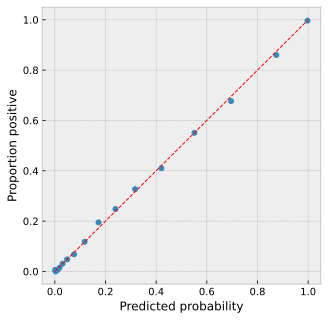

In [24]:
check_probs(probabilities[:, 1], Ytest=='>50K', step=1000)

As a comparison, we consider probabilities of an "over-confident" model. (We just take the original model's output probabilities and push them a bit more towards the extreme points.)

The result is now less similar to a diagonal line and the poorly calibrated probabilities lead to an "S-like" curve.

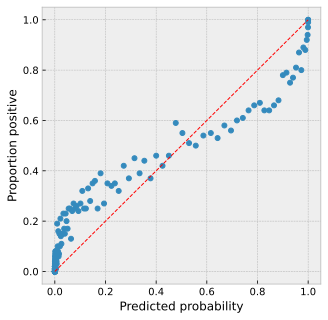

In [25]:
def logodds(p):
    p = np.clip(p, 1e-16, 1-1e-16)
    return np.log(p)-np.log(1-p)
    
def sigmoid(x):
    x = np.clip(x, -709, None)
    return 1/(1+np.exp(-x))

probs2 = sigmoid(logodds(probabilities[:, 1])*2)

check_probs(probs2, Ytest=='>50K')

Finally, we consider random probabilities that are not related to the actual predictions. This gives a flat shape.

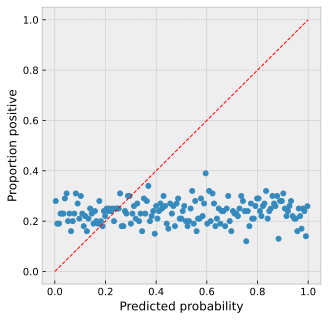

In [26]:
probs3 = np.random.uniform(size=len(Ytest))

check_probs(probs3, Ytest=='>50K')